Thanks to 
* **Modern Colorthief** - https://github.com/baseplate-admin/modern_colorthief 
* **KALMUS** - https://github.com/KALMUS-Color-Toolkit/KALMUS/tree/master

In [10]:
import cv2
from modern_colorthief import get_color, get_palette
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import colorsys
import matplotlib.pyplot as plt
import os

import numpy as np

Processing Frames:   0%|          | 0/157388 [00:00<?, ?it/s]

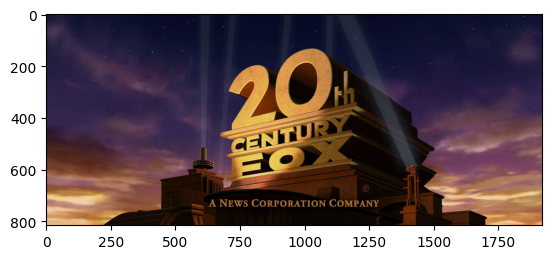

In [26]:
# Random frame test

video_path = "data/d1.mp4"
counter = 0
cap = cv2.VideoCapture(video_path)
fps, total = cap.get(5), int(cap.get(7))
pbar = tqdm(total=total, desc="Processing Frames")

while True:
    ret, frame = cap.read()
    if counter == 500:
        break
    counter += 1
    pbar.update(1)

rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
pil_image = Image.fromarray(rgb_frame)
plt.imshow(rgb_frame)

In [ ]:
success, encoded_image = cv2.imencode(".jpg", rgb_frame)
img_bytes = encoded_image.tobytes()
dominant_color = get_color(img_bytes)
color_palette = get_palette(img_bytes, color_count=5, quality=1)

((48, 33, 49),
 [(48, 33, 49),
  (88, 144, 199),
  (169, 204, 238),
  (110, 91, 135),
  (80, 132, 144)])

# Phase 1

In [ ]:
video_path = "data/h2.mp4"
counter = 0
cap = cv2.VideoCapture(video_path)
fps, total = cap.get(5), int(cap.get(7))
pbar = tqdm(total=total, desc="Processing Frames")

analysis = []

while True:
    ret, frame = cap.read()
    if not ret:
        break
    counter += 1
    pbar.update(1)

    if counter % 600 == 0:
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        success, encoded_image = cv2.imencode(".jpg", rgb_frame)
        img_bytes = encoded_image.tobytes()

        dominant_color = get_color(img_bytes)
        color_palette = get_palette(img_bytes, color_count=5, quality=1)

        analysis.append({
            "frame_no" : counter,
            "dominant_color" : dominant_color,
            "time_sec": counter / fps,
            "color_palette" : color_palette
        })

stripe_width = 7
height = 350

width = len(analysis) * stripe_width
barcode = Image.new("RGB", (width, height))
pixels = barcode.load()

for i, frame in enumerate(analysis):
    color = tuple(frame["dominant_color"])

    start_x = i * stripe_width

    for x in range(start_x, start_x + stripe_width):
        for y in range(height):
            pixels[x, y] = color

barcode.save("output/h2.png")

Processing Frames:   0%|          | 0/149255 [00:00<?, ?it/s]

In [ ]:
video_path = "data/h2.mp4"
counter = 0
cap = cv2.VideoCapture(video_path)
fps, total = cap.get(5), int(cap.get(7))
pbar = tqdm(total=total, desc="Processing Frames")

analysis = []

while True:
    ret, frame = cap.read()
    if not ret:
        break
    counter += 1
    pbar.update(1)

    if counter % 600 == 0:
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        success, encoded_image = cv2.imencode(".jpg", rgb_frame)
        img_bytes = encoded_image.tobytes()

        dominant_color = get_color(img_bytes)
        color_palette = get_palette(img_bytes, color_count=5, quality=1)

        analysis.append({
            "frame_no" : counter,
            "dominant_color" : dominant_color,
            "time_sec": counter / fps,
            "color_palette" : color_palette
        })

stripe_width = 7
height = 350

width = len(analysis) * stripe_width
barcode = Image.new("RGB", (width, height))
pixels = barcode.load()

for i, frame in enumerate(analysis):
    color = tuple(frame["dominant_color"])

    start_x = i * stripe_width

    for x in range(start_x, start_x + stripe_width):
        for y in range(height):
            pixels[x, y] = color

barcode.save("output/h2.png")

# Color palette Stacking

In [61]:
video_path = "data/m2.mp4"
counter = 0
cap = cv2.VideoCapture(video_path)
fps, total = cap.get(5), int(cap.get(7))
pbar = tqdm(total=total, desc="Processing Frames")

analysis = []

while True:
    ret, frame = cap.read()
    if not ret:
        break
    counter += 1
    pbar.update(1)

    if counter % 600 == 0:
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        success, encoded_image = cv2.imencode(".jpg", rgb_frame)
        img_bytes = encoded_image.tobytes()

        dominant_color = get_color(img_bytes)
        color_palette = get_palette(img_bytes, color_count=5, quality=1)

        analysis.append({
            "frame_no" : counter,
            "dominant_color" : dominant_color,
            "time_sec": counter / fps,
            "color_palette" : color_palette
        })



block_width = 80
block_height = 18

palette_size = 5

img_width = palette_size * block_width
img_height = len(analysis) * block_height

palette_img = Image.new(
    "RGB",
    (img_width, img_height),
    "white"
)

draw = ImageDraw.Draw(palette_img)

for row, frame in enumerate(analysis):
    palette = frame["color_palette"]
    for col, color in enumerate(palette):

        x0 = col * block_width
        y0 = row * block_height

        x1 = x0 + block_width
        y1 = y0 + block_height

        draw.rectangle([x0, y0, x1, y1],fill=tuple(color))

palette_img.save("output/m2_palette_strip.png")

Processing Frames:   0%|          | 0/212784 [00:00<?, ?it/s]

# Color Cloud

Processing Frames:   0%|          | 0/212784 [00:00<?, ?it/s]

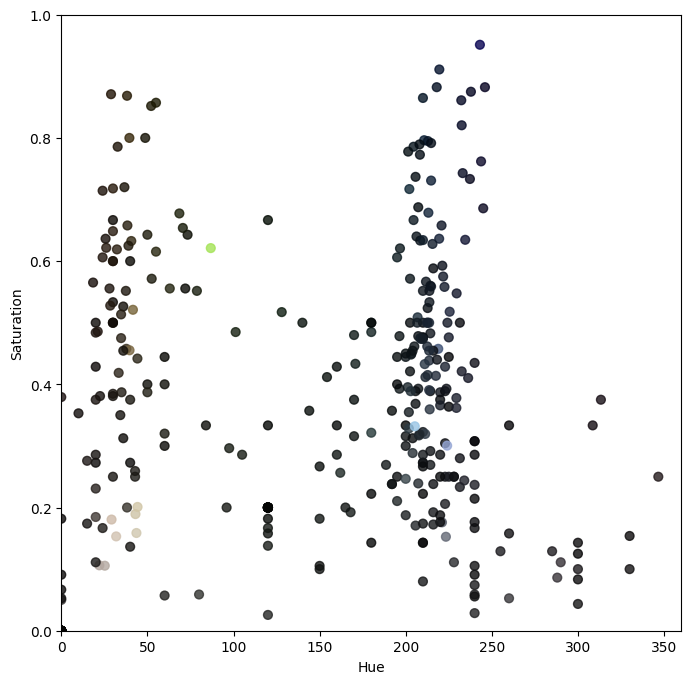

In [68]:
video_path = "data/m2.mp4"
counter = 0
cap = cv2.VideoCapture(video_path)
fps, total = cap.get(5), int(cap.get(7))
pbar = tqdm(total=total, desc="Processing Frames")

analysis = []

while True:
    ret, frame = cap.read()
    if not ret:
        break
    counter += 1
    pbar.update(1)

    if counter % 600 == 0:
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        success, encoded_image = cv2.imencode(".jpg", rgb_frame)
        img_bytes = encoded_image.tobytes()

        dominant_color = get_color(img_bytes)
        color_palette = get_palette(img_bytes, color_count=5, quality=1)

        analysis.append({
            "frame_no" : counter,
            "dominant_color" : dominant_color,
            "time_sec": counter / fps,
            "color_palette" : color_palette
        })

hues = []
sats = []
colors = []

for frame in analysis:

    r, g, b = frame["dominant_color"]

    h, s, v = colorsys.rgb_to_hsv(
        r/255,
        g/255,
        b/255
    )

    hues.append(h * 360)
    sats.append(s)

    colors.append((r/255, g/255, b/255))

plt.figure(figsize=(8,8))

plt.scatter(
    hues,
    sats,
    c=colors,
    s=40,
    alpha=0.8
)

plt.xlabel("Hue")
plt.ylabel("Saturation")

plt.xlim(0,360)
plt.ylim(0,1)

plt.savefig("output/m2_color_cloud.png", dpi=300)

# Frame animation

In [77]:
video_path = "data/m2.mp4"
counter = 0
cap = cv2.VideoCapture(video_path)
fps, total = cap.get(5), int(cap.get(7))
pbar = tqdm(total=total, desc="Processing Frames")

analysis = []

while True:
    ret, frame = cap.read()
    if not ret:
        break
    counter += 1
    pbar.update(1)

    if counter % 600 == 0:
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        success, encoded_image = cv2.imencode(".jpg", rgb_frame)
        img_bytes = encoded_image.tobytes()

        dominant_color = get_color(img_bytes)
        color_palette = get_palette(img_bytes, color_count=5, quality=1)

        analysis.append({
            "frame_no" : counter,
            "dominant_color" : dominant_color,
            "time_sec": counter / fps,
            "color_palette" : color_palette
        })


output_dir = "output/m2_animation/"
os.makedirs(output_dir, exist_ok=True)


block_width = 140
block_height = 25
row_gap = 2

palette_size = 5

img_width = palette_size * block_width


for upto in range(1, len(analysis) + 1):
    img_height = upto * (block_height + row_gap)
    #img_height = len(analysis) * (block_height + row_gap)
    img = Image.new(
        "RGB",
        (img_width, img_height),
        "black"
    )

    draw = ImageDraw.Draw(img)
    # Draw all rows accumulated so far
    for row in range(upto):
        palette = analysis[row]["color_palette"]

        y0 = row * (block_height + row_gap)
        for col, color in enumerate(palette):

            x0 = col * block_width
            x1 = x0 + block_width
            y1 = y0 + block_height

            draw.rectangle(
                [x0, y0, x1, y1],
                fill=tuple(color)
            )

    img.save(os.path.join(output_dir,f"frame_{upto:04d}.png"))

print("Done!")

Processing Frames:   0%|          | 0/212784 [00:00<?, ?it/s]

Done!


In [83]:
def video_analysis(video_path):
    #video_path 
    counter = 0
    cap = cv2.VideoCapture(video_path)
    fps, total = cap.get(5), int(cap.get(7))
    pbar = tqdm(total=total, desc="Processing Frames")

    analysis = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        counter += 1
        pbar.update(1)

        if counter % 600 == 0:
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            success, encoded_image = cv2.imencode(".jpg", rgb_frame)
            img_bytes = encoded_image.tobytes()

            dominant_color = get_color(img_bytes)
            color_palette = get_palette(img_bytes, color_count=5, quality=1)

            analysis.append({
                "frame_no" : counter,
                "dominant_color" : dominant_color,
                "time_sec": counter / fps,
                "color_palette" : color_palette
            })

    hues = []
    sats = []
    colors = []

    for frame in analysis:

        r, g, b = frame["dominant_color"]

        h, s, v = colorsys.rgb_to_hsv(
            r/255,
            g/255,
            b/255
        )

        hues.append(h * 360)
        sats.append(s)

        colors.append((r/255, g/255, b/255))
        
        return hues, sats

In [85]:
d1_hues, d1_sats = video_analysis("data/d1.mp4")
d2_hues, d2_sats = video_analysis("data/d2.mp4")

m1_hues, m1_sats = video_analysis("data/m1.mp4")
m2_hues, m2_sats = video_analysis("data/m2.mp4")
 
h1_hues, h1_sats = video_analysis("data/h1.mp4")
h2_hues, h2_sats = video_analysis("data/h2.mp4")

Processing Frames:   0%|          | 0/157388 [00:00<?, ?it/s]

Processing Frames:   0%|          | 0/173204 [00:00<?, ?it/s]

Processing Frames:   0%|          | 0/196069 [00:00<?, ?it/s]

Processing Frames:   0%|          | 0/212784 [00:00<?, ?it/s]

Processing Frames:   0%|          | 0/138295 [00:00<?, ?it/s]

Processing Frames:   0%|          | 0/149255 [00:00<?, ?it/s]

Text(0.5, 0, 'Average Saturation')

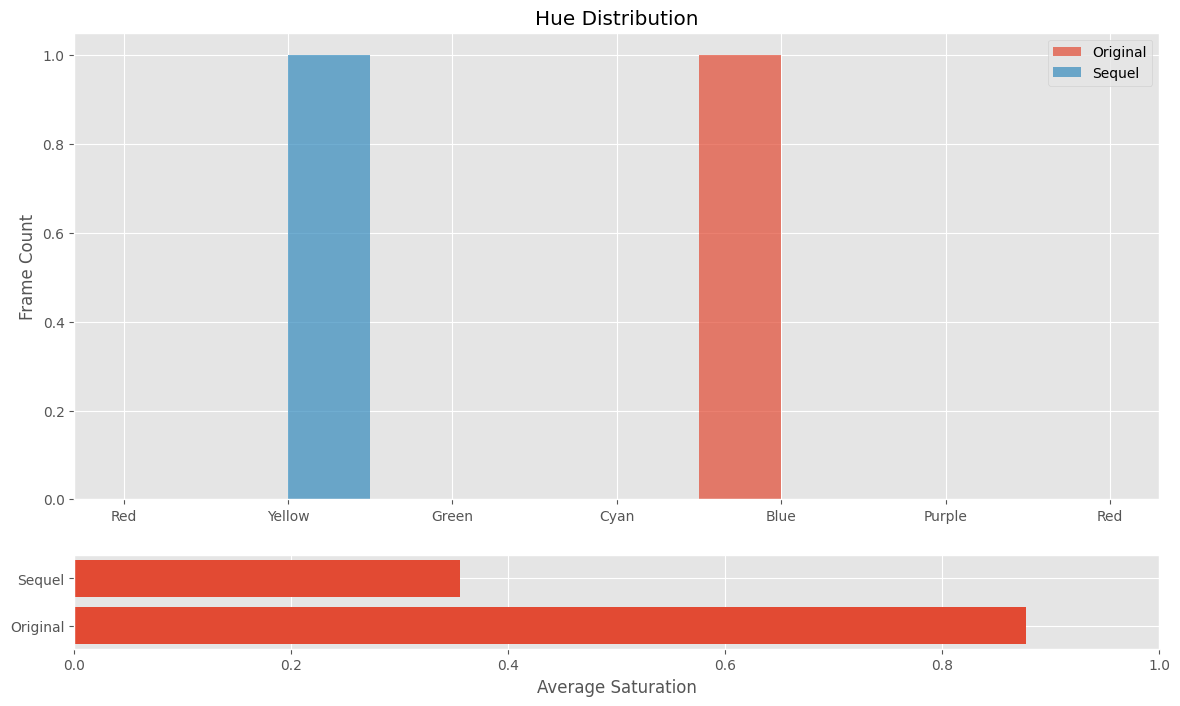

In [ ]:
#Hocus pocus 1 and 2
plt.style.use("ggplot")
bins = np.arange(0, 361, 30)

fig = plt.figure(figsize=(14,8))
gs = fig.add_gridspec(2,1,height_ratios=[5,1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

ax1.hist(h1_hues,bins=bins,alpha=0.7,label="Original")

ax1.hist(h2_hues,bins=bins,alpha=0.7,label="Sequel")

ax1.set_xticks(
    [0,60,120,180,240,300,360]
)

ax1.set_xticklabels(
    [
        "Red",
        "Yellow",
        "Green",
        "Cyan",
        "Blue",
        "Purple",
        "Red"
    ]
)

ax1.set_ylabel("Frame Count")
ax1.legend()
ax1.set_title("Hue Distribution")

avg_sat = [
    np.mean(h1_sats),
    np.mean(h2_sats)
]

ax2.barh(
    ["Original","Sequel"],
    avg_sat
)

ax2.set_xlim(0,1)
ax2.set_xlabel("Average Saturation")

Text(0.5, 0, 'Average Saturation')

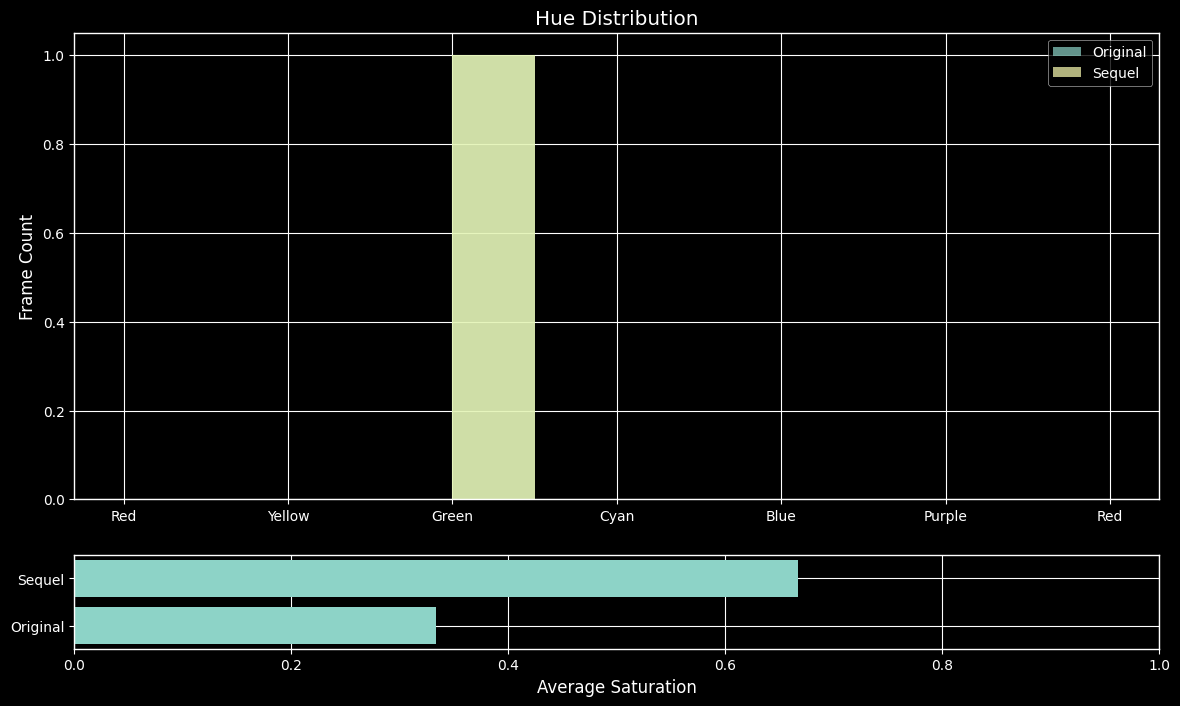

In [100]:
#Matrix 1 and 2
plt.style.use("dark_background")
bins = np.arange(0, 361, 30)

fig = plt.figure(figsize=(14,8))
gs = fig.add_gridspec(2,1,height_ratios=[5,1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

ax1.hist(m1_hues,bins=bins,alpha=0.7,label="Original")

ax1.hist(m2_hues,bins=bins,alpha=0.7,label="Sequel")

ax1.set_xticks(
    [0,60,120,180,240,300,360]
)

ax1.set_xticklabels(
    [
        "Red",
        "Yellow",
        "Green",
        "Cyan",
        "Blue",
        "Purple",
        "Red"
    ]
)

ax1.set_ylabel("Frame Count")
ax1.legend()
ax1.set_title("Hue Distribution")

avg_sat = [
    np.mean(m1_sats),
    np.mean(m2_sats)
]

ax2.barh(
    ["Original","Sequel"],
    avg_sat
)

ax2.set_xlim(0,1)
ax2.set_xlabel("Average Saturation")

Text(0.5, 0, 'Average Saturation')

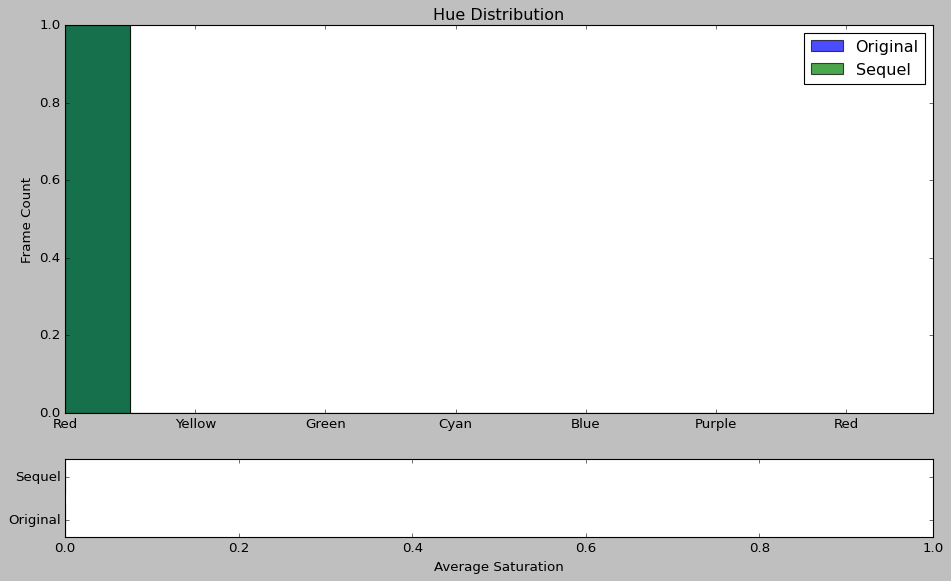

In [104]:
#Devil Wears Prada 1 and 2
plt.style.use("classic")
bins = np.arange(0, 361, 30)

fig = plt.figure(figsize=(14,8))
gs = fig.add_gridspec(2,1,height_ratios=[5,1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

ax1.hist(d1_hues,bins=bins,alpha=0.7,label="Original")

ax1.hist(d2_hues,bins=bins,alpha=0.7,label="Sequel")

ax1.set_xticks(
    [0,60,120,180,240,300,360]
)

ax1.set_xticklabels(
    [
        "Red",
        "Yellow",
        "Green",
        "Cyan",
        "Blue",
        "Purple",
        "Red"
    ]
)

ax1.set_ylabel("Frame Count")
ax1.legend()
ax1.set_title("Hue Distribution")

avg_sat = [
    np.mean(d1_sats),
    np.mean(d2_sats)
]

ax2.barh(
    ["Original","Sequel"],
    avg_sat
)

ax2.set_xlim(0,1)
ax2.set_xlabel("Average Saturation")

In [98]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

# Video Sequence Implementation

In [14]:
video_path = "data/d1.mp4"
output_path = "/Users/leonbora/Desktop/Git Projects/intelligent-system-explorations/computer_vision/single_notebook_projects/output/d1_color_evolution.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
pbar = tqdm(total=total_frames, desc="Processing Frames")

duration = total_frames / fps

print(f"FPS: {fps}")
print(f"Duration: {duration / 60:.2f} minutes")

# Sample one frame every 1 second
sample_interval = int(fps * 5)

# Output video settings
output_fps = 10
width = 1920
height = 1080

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_path,
    fourcc,
    output_fps,
    (width, height)
)

frame_number = 0
sample_count = 0

while True:

    ret, frame = cap.read()
    pbar.update(1)

    if not ret:
        break

    if frame_number % sample_interval == 0:

        # Downsize before calculating colour
        small = cv2.resize(frame, (32, 32))

        # Calculate average colour
        # OpenCV uses BGR
        avg_color = small.mean(axis=(0, 1)).astype(np.uint8)

        # Create a solid-colour frame
        color_frame = np.full(
            (height, width, 3),
            avg_color,
            dtype=np.uint8
        )

        out.write(color_frame)

        sample_count += 1

        if sample_count % 100 == 0:
            print(f"Processed {sample_count} samples")

    frame_number += 1

cap.release()
out.release()

print(f"Created: {output_path}")
print(f"Total colour frames: {sample_count}")

Processing Frames:   0%|          | 0/157388 [00:00<?, ?it/s]

FPS: 23.976023976023978
Duration: 109.41 minutes
Processed 100 samples
Processed 200 samples
Processed 300 samples
Processed 400 samples
Processed 500 samples
Processed 600 samples
Processed 700 samples
Processed 800 samples
Processed 900 samples
Processed 1000 samples
Processed 1100 samples
Processed 1200 samples
Processed 1300 samples
Created: /Users/leonbora/Desktop/Git Projects/intelligent-system-explorations/computer_vision/single_notebook_projects/output/d1_color_evolution.mp4
Total colour frames: 1323


In [21]:
video_path = "data/m2.mp4"
output_path = "/Users/leonbora/Desktop/Git Projects/intelligent-system-explorations/computer_vision/single_notebook_projects/output/m2_progressive_barcode.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
pbar = tqdm(total=total_frames, desc="Processing Frames")

duration = total_frames / fps

print(f"FPS: {fps}")
print(f"Duration: {duration / 60:.2f} minutes")

# --------------------------------------------------
# Sampling
# --------------------------------------------------

# One colour sample every 1 second
sample_interval = max(5, int(fps))

# --------------------------------------------------
# Output video
# --------------------------------------------------

width = 1920
height = 1080

# Number of barcode columns
# One column per sampled frame
num_samples = int(np.ceil(total_frames / sample_interval))

# Output video FPS
output_fps = 30

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_path,
    fourcc,
    output_fps,
    (width, height)
)

# --------------------------------------------------
# Barcode canvas
# --------------------------------------------------

barcode = np.zeros(
    (height, width, 3),
    dtype=np.uint8
)

# How many barcode samples can fit on screen
max_columns = width

frame_number = 0
sample_count = 0

while True:

    ret, frame = cap.read()
    pbar.update(1)

    if not ret:
        break

    if frame_number % sample_interval == 0:

        # Small resize is enough for average colour
        small = cv2.resize(frame, (32, 32))

        # Average BGR colour
        avg_color = small.mean(
            axis=(0, 1)
        ).astype(np.uint8)

        # ------------------------------------------
        # Add colour to barcode
        # ------------------------------------------

        if sample_count < max_columns:

            barcode[:, sample_count] = avg_color

        # ------------------------------------------
        # Write current state of barcode
        # ------------------------------------------

        out.write(barcode)

        sample_count += 1

        if sample_count % 100 == 0:
            print(f"Processed {sample_count} samples")

    frame_number += 1

cap.release()
out.release()

print(f"\nCreated: {output_path}")
print(f"Total colour samples: {sample_count}")

Processing Frames:   0%|          | 0/212784 [00:00<?, ?it/s]

FPS: 23.976023976023978
Duration: 147.91 minutes
Processed 100 samples
Processed 200 samples
Processed 300 samples
Processed 400 samples
Processed 500 samples
Processed 600 samples
Processed 700 samples
Processed 800 samples
Processed 900 samples
Processed 1000 samples
Processed 1100 samples
Processed 1200 samples
Processed 1300 samples
Processed 1400 samples
Processed 1500 samples
Processed 1600 samples
Processed 1700 samples
Processed 1800 samples
Processed 1900 samples
Processed 2000 samples
Processed 2100 samples
Processed 2200 samples
Processed 2300 samples
Processed 2400 samples
Processed 2500 samples
Processed 2600 samples
Processed 2700 samples
Processed 2800 samples
Processed 2900 samples
Processed 3000 samples
Processed 3100 samples
Processed 3200 samples
Processed 3300 samples
Processed 3400 samples
Processed 3500 samples
Processed 3600 samples
Processed 3700 samples
Processed 3800 samples
Processed 3900 samples
Processed 4000 samples
Processed 4100 samples
Processed 4200 sa